# Module 10 — Interview Prep & Portfolio Application

Part of the **A/B Testing Playbook** learning program. Full program context, progress tracker, and how this module fits with the rest: see `CURRICULUM.md`. This is the capstone — everything below draws on Modules 1-9.

## From the curriculum

> **Concepts**
> - Common product-analyst A/B testing interview formats: stats questions, experiment design cases, results-interpretation cases, product-sense hybrids
> - Building 1-2 portfolio-worthy artifacts that demonstrate this skill set end-to-end (design -> simulate/analyze -> recommend)
> - Mapping your B2B experience into interview answers where it's genuinely relevant (stakeholder management, hypothesis-driven thinking) instead of downplaying it
>
> **Why it matters**
> This is the direct job-hunt payoff — everything else is preparation for this module.
>
> **Worked example**
> Sample question: *"Walk me through how you'd A/B test a new onboarding flow."* A strong answer skeleton, pulling directly from Modules 1-9: hypothesis (Module 1) -> primary/guardrail metrics (Modules 2, 4) -> randomization unit and design (Module 4) -> sample size (Module 3) -> monitoring plan and stopping rule (Module 5) -> how you'd interpret an ambiguous result (Module 6) -> recommendation framing (Module 9). Interviewers are largely scoring whether you hit these beats in order, not just whether each individual answer is correct.
>
> **Resources** — none prescribed; this module's "reading" is largely mock practice using everything built in Modules 1-9.
>
> **Exercise type:** mock case interviews (timed or self-paced) plus a portfolio piece — likely the meatiest deliverable, and a strong candidate for the E##-style exercise format already used elsewhere.
>
> **Interview angle:** this module *is* the interview angle.

## Part 1 — The four interview formats

**Stats questions** — sample size/power arithmetic, "is this result significant," explaining a p-value or CI to a non-technical interviewer. Straight from Module 3, with Module 9's plain-language framing.

**Experiment design cases** — "design a test for X." Scored on hitting the beats in order: hypothesis with a mechanism (Module 1), the right randomization unit (Module 4), primary + guardrail metrics (Modules 2, 4), and a stated monitoring/stopping plan (Module 5) — not on getting a single "correct" design, since there often isn't one.

**Results-interpretation cases** — a results table or scenario with a trap baked in (Simpson's paradox, a segment cherry-pick, novelty effect, SRM). Modules 5, 6, and 7 are the direct toolkit; the interviewer is checking whether you reach for the same skepticism unprompted.

**Product-sense hybrids** — "what metrics would you track for X," blending Module 2's B2C metrics vocabulary with experiment design. These reward fluency more than a rigid framework.

Part 2 works one case fully end-to-end; Part 3 drills three more, one of each remaining type.

## Part 2 — Full worked case: "Walk me through how you'd A/B test a new onboarding flow"

The curriculum's own question, answered in full, with each beat labeled by the module it comes from. This is the shape every design-case answer should follow.

> **Hypothesis [Module 1]:** "If we simplify the onboarding flow from 5 steps to 2, then 7-day activation will increase, because fewer steps means fewer chances for a new user to drop off before experiencing value." Stated with a mechanism, not just a direction — and it's a genuine A/B test candidate: individual users, no interference, fast enough traffic to reach a result in a reasonable window.
>
> **Metrics [Modules 2, 4]:** Primary metric is 7-day activation rate — the proxy closest to the hypothesis itself. Guardrails: Day-30 retention (make sure a faster onboarding isn't just rushing people past steps that actually matter later) and support ticket rate (make sure we're not confusing people). These three together form the OEC: ship only if activation improves and neither guardrail regresses.
>
> **Randomization & design [Module 4]:** Randomize by user (a hashed, salted assignment, consistent across sessions) — not session, since a returning user would otherwise see both variants. Pre-register the primary metric, guardrails, and run duration before looking at any data. Plan an SRM check before trusting any result.
>
> **Sample size [Module 3]:** Given a baseline activation rate and the smallest lift worth detecting, compute the required n per arm from the two-proportion formula, then translate that into calendar time using daily signup volume — this is what actually answers "how long do we run it."
>
> **Monitoring plan [Module 5]:** No peeking-and-stop-on-significance — a single planned look at the end (or, if earlier reads are needed, a pre-committed correction). SRM and guardrails are checked continuously throughout; that's not peeking, it's a validity check.
>
> **Interpreting the result [Module 6]:** If activation is significant but the effect is tiny, that's a business call, not an automatic ship. If the result is ambiguous (CI crossing zero), that's "inconclusive," not "failed" — and worth a sample-size calculation on whether a follow-up is justified. If a segment result surfaces unprompted, apply the pre-specified/mechanism/replicable test before trusting it.
>
> **Recommendation [Module 9]:** Close with an actual recommendation in business language — effect size, CI, guardrail status, and a stated ship/hold/follow-up call — not a p-value dropped on the table and left for the interviewer to interpret.

**Why this works as an interview answer:** it's fast (each beat is one or two sentences), it's in the right order, and it never skips a beat to get to the "interesting" part — interviewers are listening for the skeleton at least as much as the specifics.

## Part 3 — Three more, one of each remaining format

**Q1 (stats question).** *"We ran a test for 2 weeks, n=1,000 per arm, saw a +3pp lift, p=0.08. The PM wants to ship. What do you say?"*

**Model answer:** Not significant at the conventional 5% bar, but that's not the same as "no effect" [Module 6] — p=0.08 with a 3pp lift suggests a real effect that this sample size wasn't quite powered to confirm. I'd run the sample-size formula backwards [Module 3]: given the observed effect size, how much more data would reliably detect it, and is that worth the extra time? I would not ship on p=0.08 alone, and I would not tell the PM "it doesn't work" either [Module 9] — the honest answer is "promising, underpowered, here's what a confirming follow-up would cost."

**Q2 (results-interpretation trap).** *"Overall the test shows a significant loss, but iOS users show a huge, significant win. Thoughts?"*

**Model answer:** Two things to check before trusting the iOS number: was it hypothesized before the test, and is there a mechanism connecting this specific change to iOS specifically [Module 6]? If neither, this is very plausibly the multiple-comparisons problem [Module 5] wearing a platform label — testing several platform cuts means some will look significant by chance. One more check before reaching for Simpson's paradox specifically [Module 7]: that label requires the aggregate to reverse relative to *every* relevant segment, not just iOS — if Android and other platforms agree with the aggregate loss and only iOS disagrees, that's not Simpson's paradox, it's a single segment behaving differently, which is squarely the mechanism/pre-specification question above, not a mix-shift artifact. Simpson's paradox becomes the live hypothesis only if *all* platform segments individually show a win while the aggregate shows a loss — worth checking the platform mix between control and treatment specifically if that's the pattern. I would not act on the iOS result without a dedicated follow-up test scoped to iOS.

**Q3 (product-sense / design hybrid).** *"We want to test whether adding a 'save for later' button increases purchases. How would you approach this?"*

**Model answer:** Hypothesis: users who aren't ready to buy today currently just leave, so a save option should increase return-and-purchase behavior later, not necessarily immediate purchases [Module 1]. That reshapes the metric choice [Module 2]: same-session conversion is the wrong primary metric for this hypothesis — a better one is purchase-within-14-days, since the mechanism is explicitly about *delayed* purchase. Guardrail: immediate same-session conversion, to make sure the button isn't giving people a reason to defer a purchase they'd have made today anyway [Module 4]. This is a good example of product sense changing the statistical design, not just sitting next to it.

## Part 4 — Translating B2B experience, briefly

| B2B skill | How it transfers | What's genuinely new |
|---|---|---|
| Stakeholder communication | Directly — Module 9 is the same skill, retargeted with CI/effect-size framing | Experimentation-specific vocabulary (guardrails, significance) |
| Hypothesis-driven thinking | Directly — B2B already reasons this way informally | Formalizing it with a testable mechanism (Module 1) and real statistical backing (Module 3) |
| Judgment under uncertainty (B2B rarely gets statistical certainty either) | Directly — Module 6's "inconclusive isn't failure" is a B2B instinct already | Having an actual CI to quantify that uncertainty instead of pure judgment |
| Small-sample reasoning (few enterprise accounts) | A real differentiator — most B2C-only candidates have never had to think this way | Module 8's toolkit (cluster randomization, diff-in-differences) *is* small-sample reasoning, formalized |
| The core statistical machinery (Modules 3-5) | Doesn't transfer — this is genuinely new | No shortcut; this is what the rest of the course was for |

In an interview: lead with the B2B experience where it's a genuine asset (design judgment, stakeholder framing, small-sample intuition from Module 8) rather than treating it as a gap to apologize for.

## Part 5 — Portfolio capstone: a full case study, end to end

A new scenario, not reused from earlier modules — a streaming service testing free trial length (7 days vs. 14 days). Design, size, simulate, analyze, and recommend, using the actual tools built across this course.

**Hypothesis [Module 1]:** if we extend the free trial from 7 to 14 days, trial-to-paid conversion will increase, because users need more time to build a habit with the product before being asked to commit financially.

**Metrics [Modules 2, 4]:** Primary: trial-to-paid conversion rate. Guardrails: Day-30 retention *among paying users* (a longer trial might attract lower-intent subscribers who churn faster once billed) and support ticket rate. OEC: ship if conversion improves and neither guardrail meaningfully regresses.

**Design [Module 4]:** Randomize by user at signup, hashed and salted. Pre-register both metrics and a fixed run duration before looking at data.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GOOD = "#1a7f37"
BAD = "#cf222e"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

def z_test_pvalue(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    p_pooled = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n1 + 1 / n2))
    return 2 * (1 - stats.norm.cdf(abs((p2 - p1) / se)))

def ci95_diff(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    diff = p2 - p1
    z = stats.norm.ppf(0.975)
    return diff - z * se, diff + z * se

def sample_size_two_proportions(p1, p2, power=0.80, alpha=0.05):
    # same formula from Module 3, built from scratch there
    z_alpha_2 = stats.norm.ppf(1 - alpha / 2)
    z_power = stats.norm.ppf(power)
    pooled_variance = p1 * (1 - p1) + p2 * (1 - p2)
    n = ((z_alpha_2 + z_power) ** 2 * pooled_variance) / (p2 - p1) ** 2
    return int(np.ceil(n))

In [2]:
baseline_conversion = 0.15
mde_conversion = 0.17  # smallest lift worth detecting: 15% -> 17%

n_needed = sample_size_two_proportions(baseline_conversion, mde_conversion, power=0.80, alpha=0.05)
n_per_arm = 5_500  # rounded up from the formula's output, with a small buffer

print(f"Sample size formula (Module 3): {n_needed:,} per arm needed to reliably detect 15% -> 17%")
print(f"Running with {n_per_arm:,} per arm -- at, say, 800 signups/day/arm, that's about {n_per_arm/800:.0f} days")

Sample size formula (Module 3): 5,271 per arm needed to reliably detect 15% -> 17%
Running with 5,500 per arm -- at, say, 800 signups/day/arm, that's about 7 days


**Simulating the experiment** — a true underlying effect exists (conversion genuinely improves; the guardrail genuinely dips slightly, but modestly enough that at this sample size it should read as inconclusive, not as a confirmed problem).

In [3]:
rng = np.random.default_rng(19)

control_converted = rng.binomial(n_per_arm, baseline_conversion)
treatment_converted = rng.binomial(n_per_arm, mde_conversion)

# guardrail: Day-30 retention, measured only among the users who actually converted --
# note this sub-population is a DIFFERENT (smaller, unequal-sized) sample than n_per_arm
control_retained = rng.binomial(control_converted, 0.70)
treatment_retained = rng.binomial(treatment_converted, 0.67)

p_primary = z_test_pvalue(control_converted, n_per_arm, treatment_converted, n_per_arm)
lo_p, hi_p = ci95_diff(control_converted, n_per_arm, treatment_converted, n_per_arm)

p_guardrail = z_test_pvalue(control_retained, control_converted, treatment_retained, treatment_converted)
lo_g, hi_g = ci95_diff(control_retained, control_converted, treatment_retained, treatment_converted)

print("PRIMARY -- trial-to-paid conversion")
print(f"  control:   {control_converted:,}/{n_per_arm:,} = {control_converted/n_per_arm:.2%}")
print(f"  treatment: {treatment_converted:,}/{n_per_arm:,} = {treatment_converted/n_per_arm:.2%}")
print(f"  lift = {(treatment_converted-control_converted)/n_per_arm*100:+.2f}pp, CI ({lo_p*100:+.2f}, {hi_p*100:+.2f})pp, p = {p_primary:.5f}")

print(f"\nGUARDRAIL -- Day-30 retention among payers (n differs: {control_converted:,} vs {treatment_converted:,} payers)")
print(f"  control:   {control_retained:,}/{control_converted:,} = {control_retained/control_converted:.2%}")
print(f"  treatment: {treatment_retained:,}/{treatment_converted:,} = {treatment_retained/treatment_converted:.2%}")
print(f"  diff = {(treatment_retained/treatment_converted - control_retained/control_converted)*100:+.2f}pp, CI ({lo_g*100:+.2f}, {hi_g*100:+.2f})pp, p = {p_guardrail:.4f}")

PRIMARY -- trial-to-paid conversion
  control:   806/5,500 = 14.65%
  treatment: 953/5,500 = 17.33%
  lift = +2.67pp, CI (+1.30, +4.04)pp, p = 0.00013

GUARDRAIL -- Day-30 retention among payers (n differs: 806 vs 953 payers)
  control:   570/806 = 70.72%
  treatment: 652/953 = 68.42%
  diff = -2.30pp, CI (-6.61, +2.01)pp, p = 0.2958


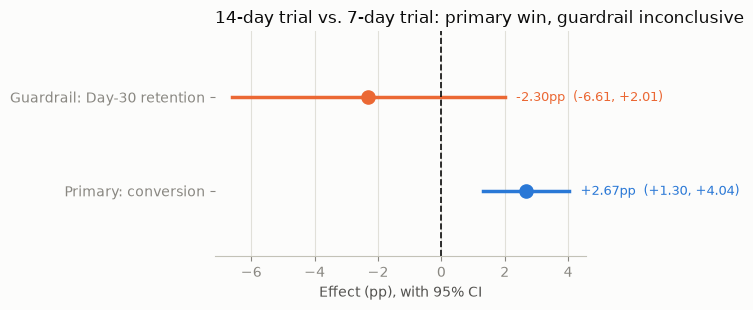

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 3.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

rows = [
    ("Primary: conversion", (treatment_converted-control_converted)/n_per_arm*100, lo_p*100, hi_p*100, BLUE),
    ("Guardrail: Day-30 retention", (treatment_retained/treatment_converted - control_retained/control_converted)*100, lo_g*100, hi_g*100, ORANGE),
]

for i, (label, mean, lo, hi, color) in enumerate(rows):
    ax.plot([lo, hi], [i, i], color=color, linewidth=2.5)
    ax.scatter([mean], [i], color=color, s=90, zorder=5)
    ax.annotate(f"{mean:+.2f}pp  ({lo:+.2f}, {hi:+.2f})", xy=(hi, i), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9, color=color)

ax.axvline(0, color=INK, linewidth=1.2, linestyle="--")
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows], color=INK)
ax.set_xlabel("Effect (pp), with 95% CI", color=INK_SECONDARY)
ax.set_title("14-day trial vs. 7-day trial: primary win, guardrail inconclusive", color=INK, fontsize=12, loc="left")
ax.set_ylim(-0.7, len(rows) - 0.3)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Interpreting the result [Module 6]:** the primary metric is significant *and* practically meaningful (+2.67pp, a genuine relative lift, `p < 0.001`) — this isn't a huge-effect-tiny-sample false alarm the way Module 6's Test A was; both the effect size and the precision are solid. The guardrail moved in the concerning direction (−2.3pp) but is not statistically significant (`p = 0.30`, CI crosses zero) — worth explicitly noting *why* it's less precise: retention is measured only among people who actually converted, which is a smaller, unequal-sized sub-sample (806 vs. 953 here) than the full experiment — guardrails conditioned on the primary outcome don't automatically inherit the primary metric's statistical power.

**Recommendation memo [Module 9]:**

> Subject: 14-day trial test — recommend shipping, with guardrail monitoring
>
> Extending the free trial from 7 to 14 days increased trial-to-paid conversion from 14.7% to 17.3% (+2.67pp, 95% CI: +1.30pp to +4.04pp, p < 0.001) — a real, meaningful lift.
>
> Day-30 retention among paying users moved in the wrong direction (−2.3pp) but is not statistically significant (95% CI: −6.6pp to +2.0pp, p = 0.30) — inconclusive, not confirmed-fine and not confirmed-broken. This guardrail is measured on a smaller sub-population (only converted users) than the primary metric, so it's naturally less precise at this sample size.
>
> **Recommendation: ship**, given the primary effect is both statistically and practically solid. **Continue monitoring Day-30 retention post-launch** at full traffic, where the larger sample will resolve whether the guardrail dip is real.

## Closing the loop

Every module in this program shows up somewhere in this capstone: Module 1's hypothesis discipline, Module 2's metric vocabulary, Module 3's sample-size formula (reused verbatim), Module 4's design and OEC, Module 5's no-peeking monitoring plan, Module 6's practical-vs-statistical read on two different metrics in the same test, Module 7's instinct to ask why the guardrail sample is smaller before treating its non-significance as reassuring, Module 9's memo format. That's the actual point of a portfolio piece — not a new technique, but proof the whole toolkit works together on a problem built from scratch.

## Key takeaways — and for the course as a whole

- Design-case answers are scored on hitting the beats in the right order (hypothesis -> metrics -> design -> size -> monitoring -> interpretation -> recommendation), not on finding one "correct" design
- A big, surprising result deserves *more* skepticism, not less (Module 7) — and a non-significant guardrail on a smaller sub-sample isn't automatically reassuring, it may just be underpowered (this module)
- B2B experience is a real asset in stakeholder framing, hypothesis discipline, and small-sample reasoning — it's the core statistical machinery (Modules 3-5) that was genuinely new, and that's now built
- The whole program's arc, in one line: correlation isn't causation (Module 1) -> you need the right statistics to say how sure you are (Module 3) -> designed correctly (Module 4) -> monitored honestly (Module 5) -> read correctly (Modules 6-7) -> extended when you can't randomize (Module 8) -> communicated so someone can actually act on it (Module 9) -> all of it, together, on a new problem (this module)

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed — the last one.*